<a href="https://colab.research.google.com/github/seo5555/seobyeol/blob/main-quest-01/%ED%83%9D%EC%8B%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 택시

## 판다스 밑 툴 로딩

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 경로 확인

In [8]:
df = pd.read_csv('/trip.csv')

## 1단계: 데이터 구조확인

데이터를 깊이 이해하고 분석 방향을 설계하기 위한 정보 기반을 마련하는 것
+ 데이터 구조 파악
  int, float, object, datetime
+ 결측치(누락 데이터) 확인
  - 어떤 컬럼에 결측치가 있고, 그 비율이 얼마나 되는지, 무시 가능한 수준인지, 처리 방법이 필요한지를 체크
+ 데이터의 분포 이해
  decribe, histm, value_counts
+ 데이터 이해 기반 마련
  pickup_time, fare, trip_distance 등

In [9]:
df.head()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22701 non-null  object 
 1   tpep_pickup_datetime   22701 non-null  object 
 2   tpep_dropoff_datetime  22701 non-null  object 
 3   payment_method         22701 non-null  object 
 4   passenger_count        22701 non-null  int64  
 5   trip_distance          22701 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22701 non-null  float64
 8   tolls_amount           22701 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.6+ MB


In [11]:
df.describe() # 통계요약

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22701.000000,22701.000000,22698.000000,22701.000000,22701.000000
mean,1.643584,2.913400,13.024009,1.835745,0.312514
std,1.304942,3.653023,13.240074,2.800537,1.399153
min,0.000000,0.000000,-120.000000,0.000000,0.000000
25%,1.000000,0.990000,6.500000,0.000000,0.000000
50%,1.000000,1.610000,9.500000,1.350000,0.000000
75%,2.000000,3.060000,14.500000,2.450000,0.000000
max,36.000000,33.960000,999.990000,200.000000,19.100000


In [12]:
df.isna().sum() # 결측치 개수

,0
passenger_name,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
payment_method,0
passenger_count,0
trip_distance,0
fare_amount,3
tip_amount,0
tolls_amount,0


이 코드에서 결측치의 수는 'fare_amount' 컬럼에서 단 3개를 보이고 있다.

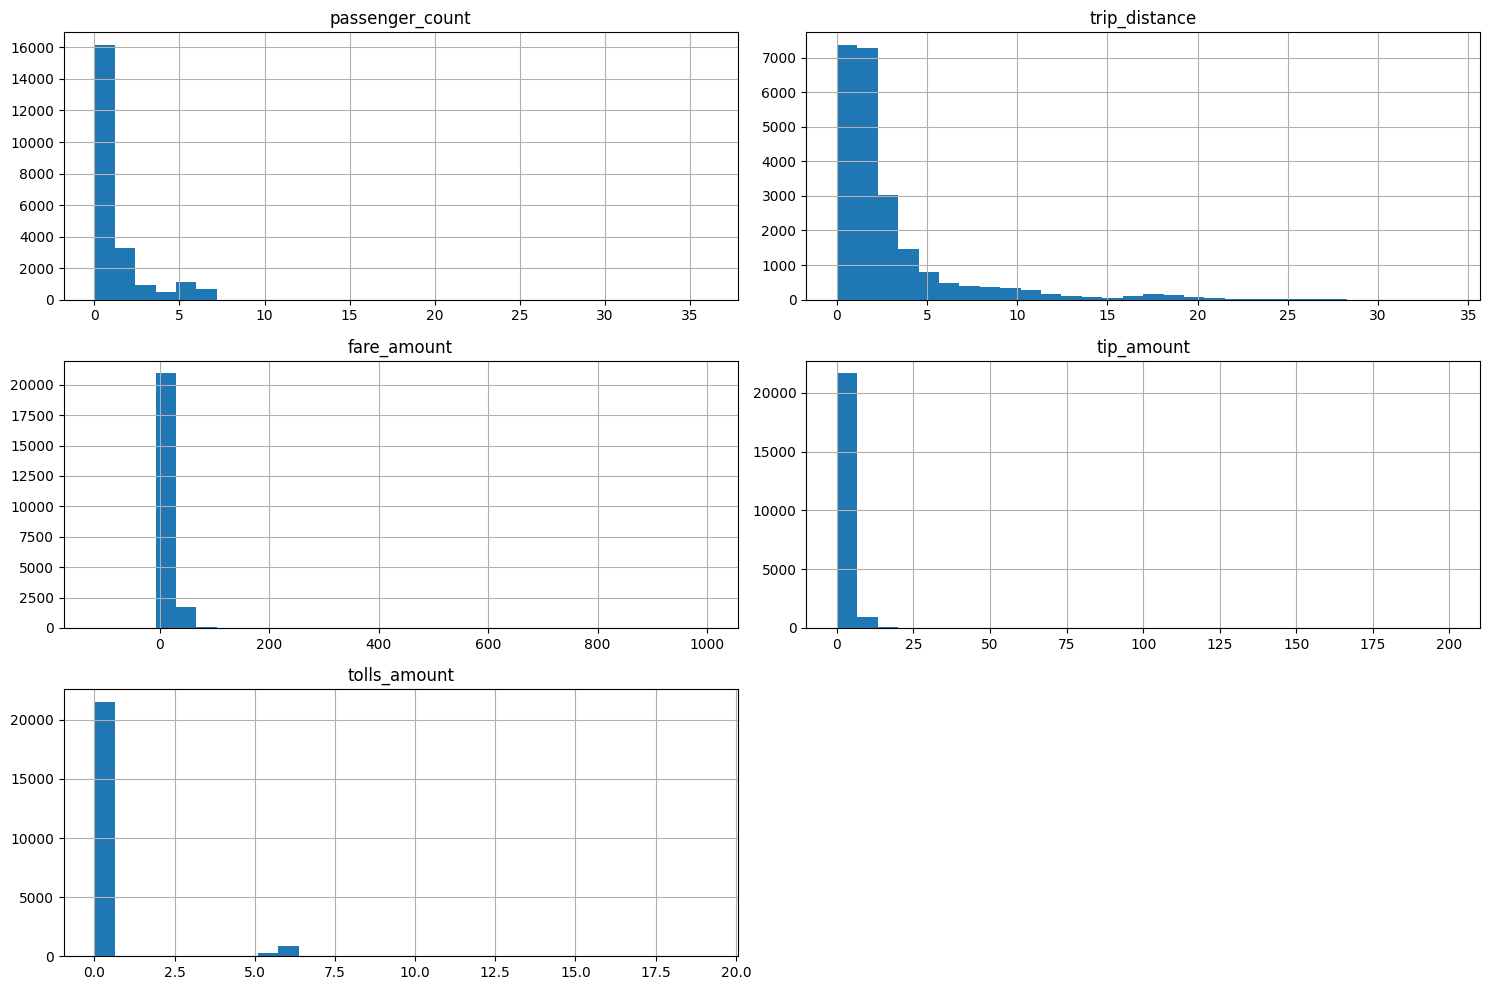

In [13]:
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

## 2단계: 결측치 및 이상치 처리

### IQR 방식(사분위 범위 기반)

In [14]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['fare_amount'] < lower) | (df['fare_amount'] > upper)]
print(outliers)

              passenger_name    tpep_pickup_datetime   tpep_dropoff_datetime  \
6               Tonya Moreno   05/03/2017 7:04:09 PM   05/03/2017 8:03:47 PM   
11               Jamie Brown   03/05/2017 7:15:30 PM   03/05/2017 7:52:18 PM   
22     Jacqueline Mclean DVM  10/11/2017 12:34:49 PM   10/11/2017 1:22:38 PM   
30              David Burton   11/06/2017 8:30:50 PM  11/07/2017 12:00:00 AM   
33                Amy Larsen  07/26/2017 11:26:50 PM  07/26/2017 11:55:49 PM   
...                      ...                     ...                     ...   
22647         Jaime Calderon  07/10/2017 10:56:44 PM  07/10/2017 11:25:16 PM   
22670       Shirley Ferguson   02/22/2017 6:45:04 AM   02/22/2017 7:19:34 AM   
22678       Ricardo Peterson  12/14/2017 12:21:01 PM  12/14/2017 12:56:21 PM   
22688        Madison Harrell   02/08/2017 6:13:26 PM   02/08/2017 7:34:11 PM   
22697       Monique Williams   08/06/2017 4:43:59 PM   08/06/2017 5:24:47 PM   

      payment_method  passenger_count  

### 시각화(박스

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


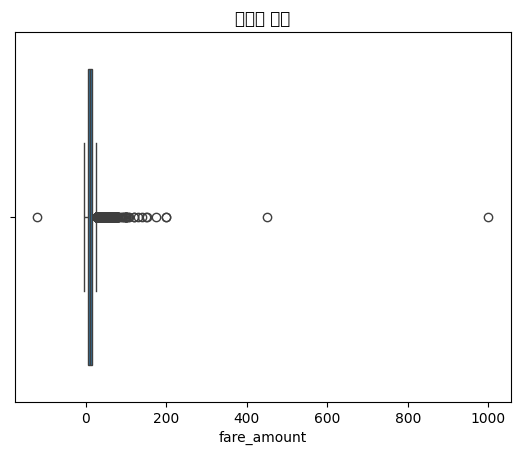

In [15]:
import seaborn as sns
sns.boxplot(x=df['fare_amount'])
plt.title('이상치 확인')
plt.show()

### 조건 기반 확인

In [16]:
df[df['fare_amount'] > 500]
df[df['trip_distance'] == 0]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
129,Linda Kaufman,06/22/2017 8:05:33 AM,06/22/2017 8:05:40 AM,Debit Card,1,0.0,20.0,0.00,0.0
248,Erik Perez,09/18/2017 8:50:53 PM,09/18/2017 8:51:03 PM,Cash,1,0.0,2.5,0.00,0.0
293,Deborah Sanford,10/04/2017 7:46:24 PM,10/04/2017 7:46:50 PM,Cash,1,0.0,2.5,0.00,0.0
321,Ryan Hughes,02/22/2017 4:01:44 AM,02/22/2017 4:01:53 AM,Cash,1,0.0,2.5,0.00,0.0
426,David Parker,01/14/2017 7:00:26 AM,01/14/2017 7:00:53 AM,Cash,1,0.0,2.5,6.70,0.0
...,...,...,...,...,...,...,...,...,...
22192,Angela French,10/16/2017 8:34:07 AM,10/16/2017 8:34:10 AM,Credit Card,1,0.0,2.5,0.00,0.0
22327,Kelsey Rogers,07/21/2017 11:30:29 PM,07/21/2017 11:31:12 PM,Debit Card,1,0.0,16.8,3.42,0.0
22385,Joseph Castillo,01/07/2017 4:48:42 AM,01/07/2017 4:51:03 AM,Cash,1,0.0,10.0,0.00,0.0
22568,Christine Edwards,03/07/2017 2:24:47 AM,03/07/2017 2:24:50 AM,Credit Card,1,0.0,0.0,0.00,0.0


### fare_amount 데이터 확인

In [17]:
df['fare_amount'].describe()

,fare_amount
count,22698.000000
mean,13.024009
std,13.240074
min,-120.000000
25%,6.500000
50%,9.500000
75%,14.500000
max,999.990000


<Axes: xlabel='fare_amount'>

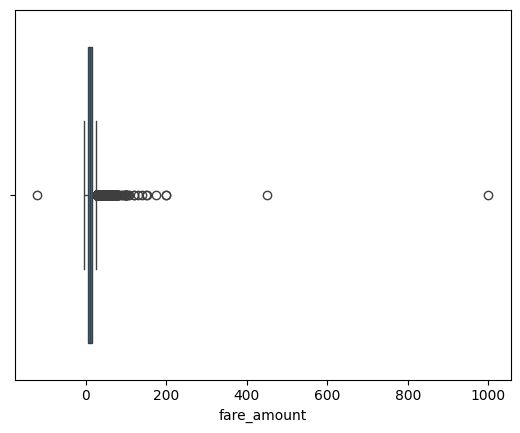

In [18]:
sns.boxplot(x=df['fare_amount'])

## 3단계 파생 변수 생성

이동 시간, 탑승 시간, 요일, 거리/시간 등등

### 탑승 및 하차 시간

In [21]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

In [22]:
df[['trip_duration_min', 'trip_distance', 'fare_amount']].describe()

,trip_duration_min,trip_distance,fare_amount
count,22701.000000,22701.000000,22698.000000
mean,17.014145,2.913400,13.024009
std,61.993817,3.653023,13.240074
min,-16.983333,0.000000,-120.000000
25%,6.650000,0.990000,6.500000
50%,11.183333,1.610000,9.500000
75%,18.383333,3.060000,14.500000
max,1439.550000,33.960000,999.990000


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

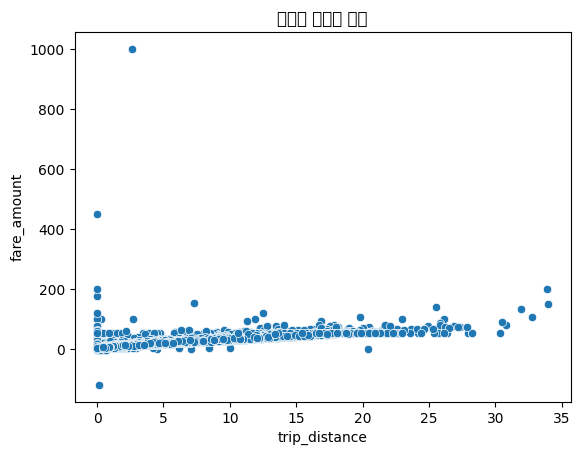

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

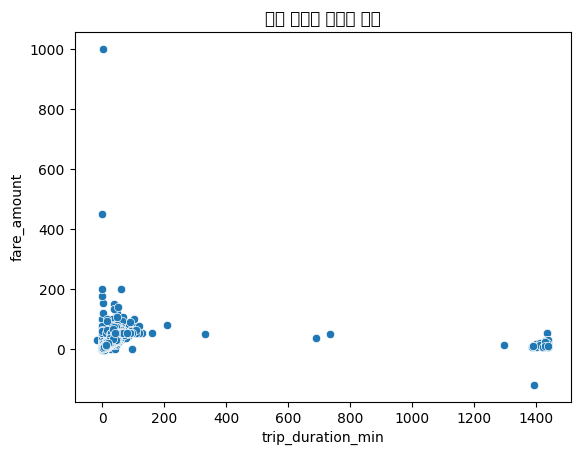

In [23]:
# 거리 vs 요금
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.title("거리와 요금의 관계")
plt.show()

# 주행시간 vs 요금
sns.scatterplot(x='trip_duration_min', y='fare_amount', data=df)
plt.title("주행 시간과 요금의 관계")
plt.show()

In [24]:
trip_speed = trip_distance / (trip_duration_min / 60)

NameError: name 'trip_distance' is not defined

### 카드 통합

In [25]:
df['payment_method'] = df['payment_method'].replace({
    'Credit Card': 'Card',
    'Debit Card': 'Card'
})

In [26]:
df['payment_method'].value_counts()

,count
payment_method,
Card,11505
Cash,11196
